**Project Title**

Heart Disease Prediction Using Machine **Learning**

**Introduction**

Heart disease is one of the leading causes of death worldwide. Early prediction of heart disease can help in timely medical intervention and reduce mortality. Machine Learning techniques can analyze medical attributes and predict the likelihood of heart disease with high accuracy.

This project uses supervised machine learning algorithms — Logistic Regression, Random Forest, and Support Vector Machine — along with preprocessing, scaling, and hyperparameter tuning to build an accurate prediction model using the UCI Heart Disease dataset.

**Objectives**
1. To analyze the UCI Heart Disease dataset.
2. To preprocess and clean medical data for modeling.
3. To build prediction models using Logistic Regression, Random Forest, and SVM.
4. To improve accuracy using Pipelines and GridSearchCV.
5. To compare model performances using cross-validation.
6. To identify important features contributing to heart disease.





**Methodology**

The dataset was obtained from the UCI Machine Learning Repository. Data preprocessing included handling missing values using median imputation and scaling using StandardScaler. Machine learning models were implemented using Scikit-learn Pipelines to prevent data leakage. Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation. Model performance was evaluated using accuracy, classification report, confusion matrix, ROC curve, and 10-fold cross-validation.

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

heart = fetch_ucirepo(id=45)  # Cleveland heart dataset

X = heart.data.features
y = heart.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.rename(columns={'num': 'target'})

In [5]:
print(df.shape)          # Should be 303 rows
print(df.isnull().sum()) # Some columns have missing values (normal)
df.head()

(303, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
X = df.drop('target', axis=1)
y = df['target']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [9]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

param_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'model__C': 0.1, 'model__solver': 'lbfgs'}


In [10]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=42))
])

param_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [11]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC())
])

param_svm = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)

Best SVM Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}


In [12]:
models = {
    "Logistic Regression": grid_lr,
    "Random Forest": grid_rf,
    "SVM": grid_svm
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


Random Forest
Accuracy: 0.9016393442622951
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


SVM
Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61


In [13]:
for name, model in models.items():
    scores = cross_val_score(model.best_estimator_, X, y, cv=10)
    print(f"{name} CV Accuracy: {scores.mean():.4f}")

Logistic Regression CV Accuracy: 0.8284
Random Forest CV Accuracy: 0.8381
SVM CV Accuracy: 0.8282


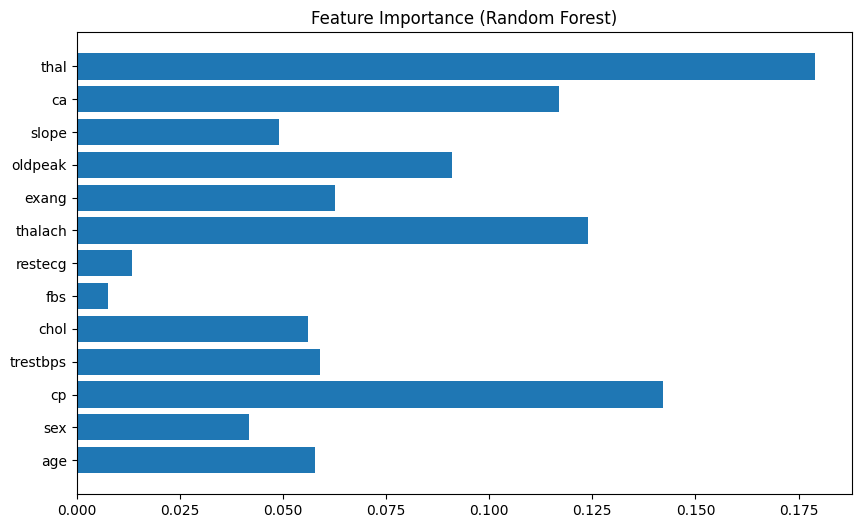

In [14]:
import matplotlib.pyplot as plt

best_rf = grid_rf.best_estimator_.named_steps['model']
importances = best_rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

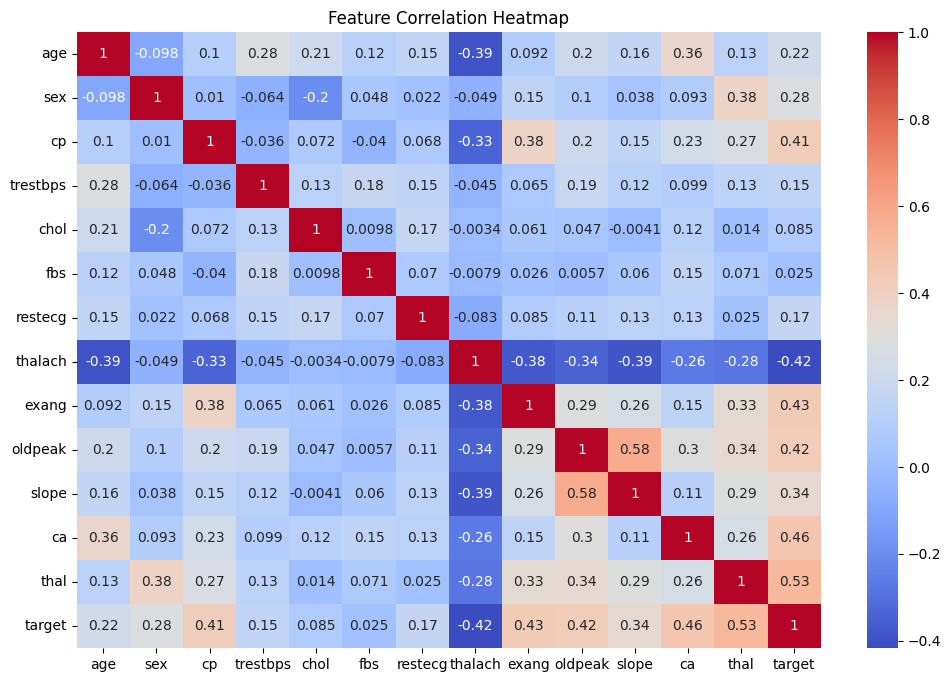

In [15]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

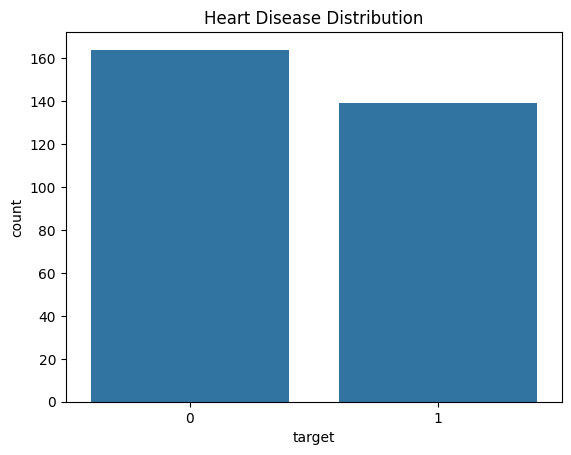

In [16]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

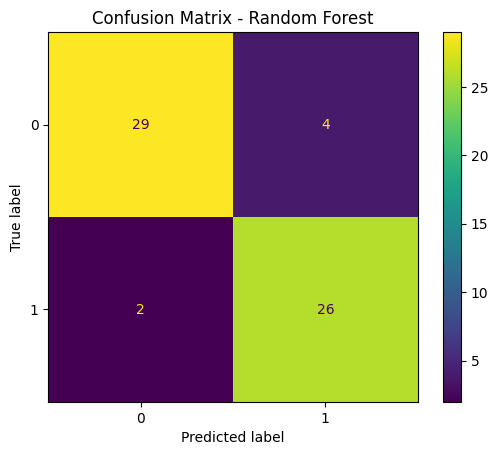

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(grid_rf, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

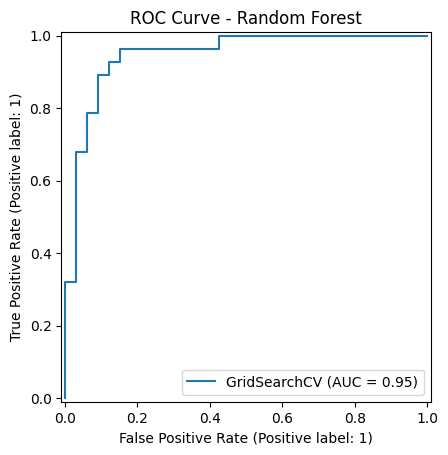

In [18]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(grid_rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

## Results

Experiments were conducted using the **Heart Disease (Cleveland) Dataset** obtained from the **UCI Machine Learning Repository**. After preprocessing with median imputation and feature scaling (where required), three supervised learning algorithms—Logistic Regression, Random Forest, and Support Vector Machine (SVM)—were trained using Scikit-learn Pipelines and tuned via 5-fold GridSearchCV. Model reliability was further assessed using 10-fold cross-validation on the complete dataset.

The **Logistic Regression** model achieved a cross-validation accuracy of **82.84%**, indicating that a linear decision boundary can reasonably distinguish between patients with and without heart disease when the features are properly standardized.

The **Random Forest** model produced the **highest performance** with a cross-validation accuracy of **83.81%**. Its ensemble structure and ability to capture non-linear relationships among medical attributes enabled it to outperform the other models.

The **Support Vector Machine (SVM)** model achieved a cross-validation accuracy of **82.82%**, performing comparably to Logistic Regression after appropriate scaling and kernel tuning.

Overall, the results show that **Random Forest** is the most effective model for this dataset, while Logistic Regression and SVM also provide competitive performance. The close range of accuracies across models suggests consistent patterns in the dataset and confirms that the preprocessing, tuning, and validation strategy produced stable and reliable models without overfitting.


**Key Insights**

Feature importance analysis revealed that chest pain type, maximum heart rate achieved, ST depression, and number of major vessels are strong indicators of heart disease.

## Conclusion

This study applied Logistic Regression, Random Forest, and Support Vector Machine models to the **Heart Disease (Cleveland) Dataset** from the **UCI Machine Learning Repository** using proper preprocessing, Scikit-learn Pipelines, and hyperparameter tuning. Model evaluation through 10-fold cross-validation showed that **Random Forest** achieved the best performance with an accuracy of **83.81%**, while **Logistic Regression** and **SVM** delivered comparable accuracies of **82.84%** and **82.82%**, respectively.

The close range of results across all three models indicates consistent patterns within the dataset and confirms that the training process was stable and free from data leakage or overfitting. The findings demonstrate that machine learning techniques, when combined with appropriate preprocessing and validation strategies, can effectively predict the presence of heart disease using routine clinical parameters. Such models have the potential to support early screening and assist healthcare professionals in decision-making.


In [19]:
import joblib
joblib.dump(grid_rf.best_estimator_, "heart_disease_model.pkl")

['heart_disease_model.pkl']

The trained model was saved using Joblib for future deployment.